# Pseudomode mapping for spin-boson model with Ohmic bath

This notebook applies the approach of (Pleasance et al) to simulate the reduced system dynamics of the spin-boson model with an Ohmic bath.

The Hamiltonian of a generic open system model with bosonic bath is given by 
\begin{align*}
    H &= H_S + H_B + H_{SB} \\
      &= H_S + \sum_k\omega_ka^{\dagger}_ka_k + X\otimes B,
\end{align*}
where $X = X^{\dagger}$ and $B = g^*_ka_k + g_ka^{\dagger}_k$ are open system and bath operators, respectively. 
Moreover, the bath is initially in the thermal state $\rho_B = \exp(-\beta H_B)/{\rm Tr}[\exp(-\beta H_B)]$ with inverse temperature $\beta$. 

The bath correlation function (BCF) $C^B(t) = {\rm Tr}[e^{iH_Bt}Be^{-iH_Bt}B\rho_B]$ for an Ohmic-like spectral density of the form $J(\omega) = \alpha\omega^s\omega^{1-s}_ce^{-\omega/\omega_c}$ admits the analytical form
\begin{equation*}
    C^B(t) = \frac{\alpha}{\pi}\omega^{1-s}_c\beta^{-(s+1)}\Gamma(s+1)\bigg[
        \zeta\left(s+1, \frac{1 - \beta\omega_c - i\omega_ct}{\beta\omega_c}\right) + \zeta\left(s+1, \frac{1 + i\omega_ct}{\beta\omega_c}\right)\bigg],
\end{equation*}
where $\Gamma(s+1) = s!$  is the Gamma function, and $\zeta(s,x)$ is the (generalised) zeta function
\begin{equation*}
    \zeta(s,x) = \sum^{\infty}_{n=0}\frac{1}{(n+x)^s}. 
\end{equation*}

## Fitting of bath correlation function

To extract the pseudomode parameters, we first need to fit $C^B(t)$ to a sum of $N$ complex exponentials
\begin{equation*}
    C^E(t) = -i\sum^N_{i=1}r_ie^{-iz_it},
\end{equation*}
where $z_i$ denote pole locations of $\gamma^E(\omega) = \int^{\infty}_{-\infty}dt\,C^E(t)e^{i\omega t}$ in the lower half complex $\omega$-plane, and are $r_i$ their corresponding residues.

In [90]:
import numpy as np
import qutip as qt
import matplotlib.pyplot as plt
import matplotlib as mpl 
from scipy.linalg import expm
from numpy import linalg

#import sys
#sys.path.append('/Users/GraemePleasance/Documents/PM theory 3/Python')

We consider an Ohmic spectral density ($s=1$):
\begin{equation*}
    J(\omega) = \alpha\omega e^{-\omega/\omega_c}. 
\end{equation*}

In [87]:
# Parameters (units of system energy om_0)
T = 0.5
om_cut = 5
s = 1
N_exp = 5
alph = 0.5

tlist = np.linspace(0, 5, 500)
omlist = np.linspace(-10, 20, 500)

In [88]:
# Fit bath correlation function with N_exp complex exponentials ck * exp(-vk * t)
bath = qt.OhmicEnvironment(T=T, alpha=alph, wc=om_cut, s=s)
approx_env, info = bath.approximate("prony", tlist, Nr=N_exp)

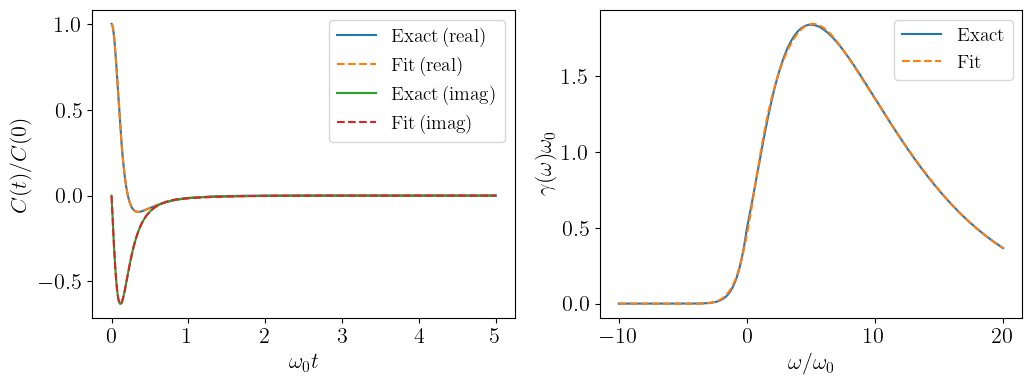

In [57]:
#matplotlib.rcParams['figure.figsize'] = (7, 5)
mpl.rcParams['axes.labelsize'] = 16
mpl.rcParams['xtick.labelsize'] = 16
mpl.rcParams['ytick.labelsize'] = 16
mpl.rcParams['legend.fontsize'] = 14
mpl.rcParams['text.usetex'] = True

fig1, ax1 = plt.subplots(1,2, figsize=(12,4))

C0 = np.real(bath.correlation_function([0])[0]) 

# Bath correlation function
# Real part
ax1[0].plot(tlist, np.real(bath.correlation_function(tlist)) / C0, label = r'$\mathrm{Exact \, (real)}$')
ax1[0].plot(tlist, np.real(approx_env.correlation_function(tlist)) / C0, linestyle='--', label = r'$\mathrm{Fit \, (real)}$')
# Imaginary part (Im C(0) = 0)
ax1[0].plot(tlist, np.imag(bath.correlation_function(tlist)) / C0, label = r'$\mathrm{Exact \, (imag)}$')
ax1[0].plot(tlist, np.imag(approx_env.correlation_function(tlist)) / C0, linestyle='--', label = r'$\mathrm{Fit \, (imag)}$')

ax1[0].set_xlabel(r'$\omega_0t$')
ax1[0].set_ylabel(r'$C(t)/C(0)$')
ax1[0].legend()

# Bath spectrum
ax1[1].plot(omlist, bath.power_spectrum(omlist), label=r'$\mathrm{Exact}$')
ax1[1].plot(omlist, approx_env.power_spectrum(omlist), linestyle='--', label=r'$\mathrm{Fit}$')

ax1[1].set_xlabel(r'$\omega/\omega_0$')
ax1[1].set_ylabel(r'$\gamma(\omega)\omega_0$')
ax1[1].legend()

plt.show()

In [58]:
print(info['summary'], '\n')

print(r'C(0) =', C0)

Result of fitting Correlation Function with 5 terms: 
 
 Parameters|   ckr    |   cki    |   vkr    |  vki 
 1         |-3.15e-02 |-9.65e-03 | 2.07e+01 |4.38e+01
 2         |-3.03e-01 | 5.98e-01 | 1.47e+01 |2.34e+01
 3         | 1.94e+00 | 1.73e+00 | 9.53e+00 |1.13e+01
 4         |-1.88e-01 |-9.06e-01 | 2.29e+00 |4.00e-01
 5         | 2.68e+00 |-1.41e+00 | 5.22e+00 |4.06e+00
 
A RMSE of  3.90e-05-1.27e-05j was obtained for the Correlation Function.
The current fit took  0.317054 seconds. 

C(0) = 4.092931899686425


### Pseudomode parameters

Re-express fitted correlation function in the form 
\begin{equation}
C^E(t) = \boldsymbol{r}^Te^{-i\boldsymbol{\Lambda} t}\boldsymbol{r}
\end{equation}
for $t\geq0$, where $\boldsymbol{\Lambda} = {\rm diag}(z_1,...,z_N)$ and $\boldsymbol{r} = (\sqrt{-ir_1},...,\sqrt{-ir_N})^T$.

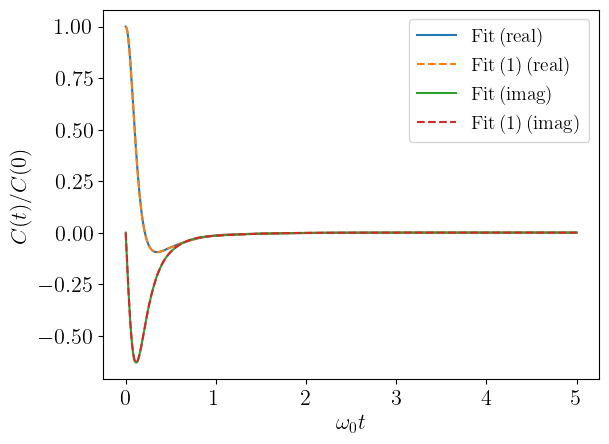

In [59]:
# Square root of complex coefficients 
r = np.array([np.sqrt(p[0] + 1j*p[1]) for p in info['params']])
Lmb = [-p[2] - 1j*p[3] for p in info['params']]
Lmb = 1j*np.diag(Lmb)

fig3, ax3 = plt.subplots()

ax3.plot(tlist, np.real(approx_env.correlation_function(tlist)) / C0, label=r'$\mathrm{Fit \, (real)}$')
ax3.plot(tlist, [np.real(np.array(r.T.dot(expm(-1j*Lmb*t).dot(r)))) / C0 for t in tlist], linestyle='--', label=r'$\mathrm{Fit \, (1) \, (real)}$')
ax3.plot(tlist, np.imag(approx_env.correlation_function(tlist)) / C0, label=r'$\mathrm{Fit \, (imag)}$')
ax3.plot(tlist, [np.imag(np.array(r.T.dot(expm(-1j*Lmb*t).dot(r)))) / C0 for t in tlist], linestyle='--', label=r'$\mathrm{Fit \, (1) \, (imag)}$')

ax3.set_xlabel(r'$\omega_0t$')
ax3.set_ylabel(r'$C(t)/C(0)$')
ax3.legend()

We now look to extract the pseudomode parameters $\boldsymbol{g}$ (system-pseudomode couplings) and $\boldsymbol{Z}$ (self energies, internal couplings and decay rates) via a gauge transformation $\{\boldsymbol{r},\boldsymbol{\Lambda}\} \rightarrow \{\boldsymbol{g},\boldsymbol{Z}\}$ of the BCF.

To this end, we employ the ansatz $g = \boldsymbol{U}\boldsymbol{r}$, $\boldsymbol{Z} = \boldsymbol{U}\boldsymbol{\Lambda}\boldsymbol{U}^T$, where  
\begin{equation*}
    \boldsymbol{U} = \boldsymbol{S}e^{i\boldsymbol{R}},
\end{equation*}
and $\boldsymbol{S}^T = \boldsymbol{S}^{-1}$, $\boldsymbol{R} = -i\alpha(\boldsymbol{r}^*\boldsymbol{r}^T - \boldsymbol{r}\boldsymbol{r}^{\dagger})$. 

Note this always results in real couplings 
\begin{equation*}
        \boldsymbol{g} = \frac{1}{\sqrt{2(\mu+1)}}\boldsymbol{S}(\boldsymbol{r} + \boldsymbol{r}^*),
\end{equation*}
but potentially nonpositive $\boldsymbol{\gamma} = -2\,{\rm Im}\,\boldsymbol{Z} = {\rm diag}(\gamma_1,...,\gamma_N)$.

NB: typically observed that only one decay rate of $\boldsymbol{\gamma}$ is negative for $N>2$ (partly consequence of trace preservation ${\rm Tr}[\boldsymbol{\gamma}] = -2\sum_k{\rm Im}\,z_k$).


The parameters $\{\boldsymbol{g},\boldsymbol{Z}\}$ can be mapped directly onto the pseudomode master equation (PMME)
\begin{equation*}
    \dot{\rho} = -i[H_0,\rho] + \sum^N_{k=1}\gamma_k\Big(b_k\rho b^{\dagger}_k - \tfrac{1}{2}\{b^{\dagger}_kb_k,\rho\}\Big)
\end{equation*}
where $H_0 = H_S + H_E + H_{SE}$, and
\begin{align*}
    H_E &= \sum_{k,l}\xi_{kl}b^{\dagger}_kb_l, \\
    H_{SE} &= X \otimes \sum_k g_k(b_k + b^{\dagger}_k),
\end{align*}
with $\boldsymbol{\xi} = {\rm Re}\,\boldsymbol{Z}$. 

NB: since $\gamma_k$ can potentially be negative, the PMME will generally be in quasi-GKSL form. 

In [60]:
# Pseudomode parameters
r = r / np.sqrt(C0)

# CHECK
mu = r.dot(np.conj(r))
alpha = (1/(np.sqrt(mu*mu-1))) * np.arctanh(np.sqrt((mu-1)/(mu+1))) 

theta = alpha * np.sqrt(mu*mu-1)

# exp of R matrix
exp_R = np.identity(len(r)) + (1/(mu*mu-1)) * ((np.cosh(theta)*(2*mu-1)-mu) * np.outer(np.conj(r), r)
                                          - (mu - np.cosh(theta)) * np.outer(r, np.conj(r))
                                          - (np.cosh(theta)-1) * np.outer(r, r)
                                          - (np.cosh(theta)-1) * np.outer(np.conj(r), np.conj(r)))

# First part of transformation
gm_0 = -2 * np.imag(exp_R.dot(Lmb.dot(exp_R.T)))  # check
xi_0 = np.real(exp_R.dot(Lmb.dot(exp_R.T)))

S = linalg.eig(gm_0)[1].T  # obtain S from eigenvectors of gm_0

# Pseudomode coupling + decay rates
xi = S.dot(xi_0.dot(S.T))
gm = S.dot(gm_0.dot(S.T))
# System-pseudomode couplings
g = np.sqrt(C0) * S.dot((1/(np.sqrt(2*(mu+1))))*(r + np.conj(r)))

print('g = ')
print(np.real(g))
print('\n')
print('xi = ')
print(xi)
print('\n')
print('gamma = ')
print(np.diag(gm))

g = 
[ 1.70574836 -0.73843705  0.3431507  -0.00203094 -0.72125687]


xi = 
[[ 7.59498673 -3.43368479 -7.80264254 -9.41679683 -4.36862764]
 [-3.43368479  2.71802094  4.15009247  1.89950352 -1.13810504]
 [-7.80264254  4.15009247 40.16040714 -7.39024997  2.30767355]
 [-9.41679683  1.89950352 -7.39024997 21.72610238 -4.2429594 ]
 [-4.36862764 -1.13810504  2.30767355 -4.2429594  10.71230182]]


gamma = 
[-7.56730743  8.41803348 43.14901681 37.42308418 23.56353841]


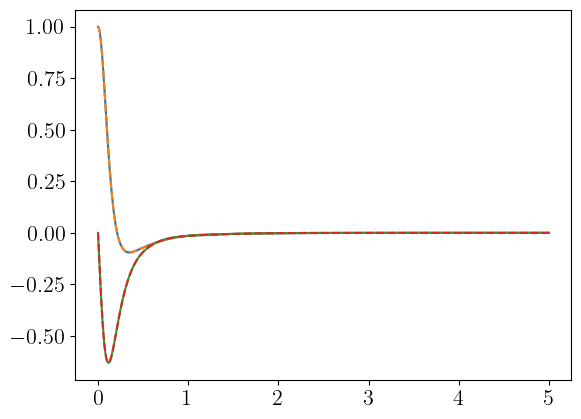

In [61]:
# Plot pseudomode correlation function with parameters {g, Z} against correlation fit
Z  = xi - 0.5*1j*gm
g = np.real(g)
corr_pm = np.array([g.T.dot(expm(-1j*Z*t).dot(g)) for t in tlist])

fig4, ax4 = plt.subplots()
ax4.plot(tlist, np.real(approx_env.correlation_function(tlist)) / C0, label='Exact (real)')
ax4.plot(tlist, (np.real(corr_pm)) / C0, '--', label='PM (real)')
ax4.plot(tlist, np.imag(approx_env.correlation_function(tlist)) / C0, label='Exact (imag)')
ax4.plot(tlist, np.imag(corr_pm) / C0, '--', label='PM (imag)')

## PMME simulation: independent boson model (IBM)

To benchmark the PMME results, we consider an exactly solvable version of the spin-boson model - the independent boson model - where the system undergoes a purely dephasing dynamics:
\begin{equation*}
 H = \frac{\omega_0}{2}\sigma_z + \sum_k\omega_ka^{\dagger}_ka_k + \sigma_z\otimes B.
\end{equation*}
The system Bloch vector in this case evolves according to
\begin{equation*}
    \begin{pmatrix}
    \langle \sigma_x(t)\rangle \\ 
    \langle \sigma_y(t)\rangle \\ 
    \langle \sigma_z(t)\rangle
    \end{pmatrix}
    =
    \begin{pmatrix}
    2\,{\rm Re}[e^{i\omega_0 t + \phi(t)}\rho_{10}] \\ 
    2\,{\rm Im}[e^{i\omega_0 t + \phi(t)}\rho_{10}]  \\ 
    \langle \sigma_z(0)\rangle
    \end{pmatrix},
\end{equation*}
where $\rho_{10} = \langle 1|\rho_S(t)|0\rangle$, and 
\begin{equation*}
    \phi(t) = -\frac{4}{\pi}\int^{\infty}_0d\omega\frac{J(\omega)}{\omega^2}\coth\left(\frac{\beta\omega}{2}\right)(1-\cos\omega t).
\end{equation*}


In [80]:
tlist_pm = np.linspace(0, 10, 500)

# Local PM dims
N1, N2, N3, N4, N5 = 7, 2, 3, 4, 3
Nlist = [N1, N2, N3, N4, N5]

# Initial system + PM state
init_state = qt.tensor([qt.ket2dm((qt.basis(2) + qt.basis(2,1)).unit())] + [qt.fock_dm(N) for N in Nlist])

sigx = qt.tensor([qt.sigmax()] + [qt.identity(N) for N in Nlist])
sigy = qt.tensor([qt.sigmay()] + [qt.identity(N) for N in Nlist])
sigz = qt.tensor([qt.sigmaz()] + [qt.identity(N) for N in Nlist])

b_ops = []
for n in range(len(Nlist)): 
  b_ops.append(qt.tensor([qt.identity(2)] + [qt.destroy(N) if n == idx else qt.identity(N) for idx, N in enumerate(Nlist)]))


In [81]:
# Hamiltonian
H_S = 1/2 * sigz
H_E = 0 
H_I = 0
for i in range(len(b_ops)):
    H_I += g[i] * sigz * (b_ops[i] + b_ops[i].dag())
    for j in range(len(b_ops)):
        H_E += xi[i][j] * b_ops[i].dag() * b_ops[j] 

H = H_S + H_E + H_I

In [ ]:
# Construct GKSL part of dissipator
L_sys_pm = qt.liouvillian(H=H, c_ops=[np.sqrt(dr) * b_ops[i] if dr > 0 else 0 * b_ops[i] for i, dr in enumerate(np.diag(gm))])

# Add non-GKSL part (negative decay rates)
for i, dr in enumerate(np.diag(gm)):
    if dr < 0:
        L_sys_pm -= qt.lindblad_dissipator(a=np.sqrt(np.abs(dr)) * b_ops[i])

In [83]:
# Solve quasi-Lindblad ME
result = qt.mesolve(L_sys_pm, init_state, tlist_pm, e_ops=[sigx, sigy] + [op.dag() * op for op in b_ops], options={'progress_bar': True})

10.0%. Run time:  42.61s. Est. time left: 00:00:06:22
20.0%. Run time:  80.60s. Est. time left: 00:00:05:21
30.1%. Run time: 118.57s. Est. time left: 00:00:04:35
40.1%. Run time: 157.33s. Est. time left: 00:00:03:55
50.1%. Run time: 195.56s. Est. time left: 00:00:03:14
60.1%. Run time: 234.45s. Est. time left: 00:00:02:35
70.1%. Run time: 273.53s. Est. time left: 00:00:01:56
80.2%. Run time: 311.93s. Est. time left: 00:00:01:17
90.2%. Run time: 351.65s. Est. time left: 00:00:00:38
100.0%. Run time: 389.73s. Est. time left: 00:00:00:00
Total run time: 389.74s


NB: system-pseudomode dynamics can show numerical instabilities. 
- Consider transformation that shifts negative decay rate to non-Hermitian system-pseudomode interaction? Could help stablize dynamics.

## Benchmarking

Relative error for each Bloch component $\langle\sigma_i(t)\rangle$,
\begin{equation*}
    \epsilon_i = \frac{|\Delta\langle\sigma_i(t)\rangle|}{|\langle\sigma_i(t)\rangle|},
\end{equation*}
where $\Delta\langle\sigma_i(t)\rangle = \langle\sigma_i(t)\rangle - {\rm Tr}[(\sigma_i\otimes\mathbb{I}_E)\rho(t)]$.

/var/folders/cl/lf0z7k5n0p91rtvfr_fc1hr00000gn/T/ipykernel_91624/2932084739.py:23: RuntimeWarning: invalid value encountered in divide
  ax5[1].plot(tlist_pm, 100 * np.abs(evolved_bloch_vector[1] - result.expect[1]) / (np.abs(evolved_bloch_vector[1])), label=r'$i=y$')


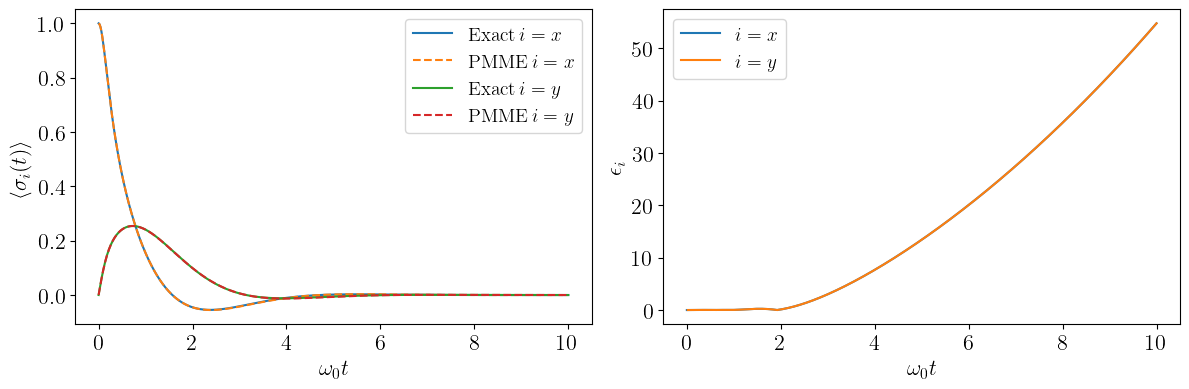

In [91]:
from pseudomodes.pure_dephasing import dephase_exp

# Initial Bloch vector (derive from init_state)
init_tls_state = init_state.ptrace(0)

bloch_vector = np.array([qt.expect(qt.sigmax(),init_tls_state), qt.expect(qt.sigmay(),init_tls_state), qt.expect(qt.sigmaz(),init_tls_state)])

# Compute time-evoled Bloch vector from dephase_exp (decoherence function)
evolved_bloch_vector = dephase_exp(tlist_pm, bloch_vector, eps=1, T=T, alph=alph, w_cut=om_cut, s=s)

fig5, ax5 = plt.subplots(1,2, figsize=(12,4))

ax5[0].plot(tlist_pm, evolved_bloch_vector[0], label=r'$\mathrm{Exact} \, i=x$')
ax5[0].plot(tlist_pm, result.expect[0], linestyle='--', label=r'$\mathrm{PMME} \, i=x$')
ax5[0].plot(tlist_pm, evolved_bloch_vector[1], label=r'$\mathrm{Exact} \, i=y$')
ax5[0].plot(tlist_pm, result.expect[1], linestyle='--', label=r'$\mathrm{PMME} \, i=y$')

ax5[0].set_xlabel(r'$\omega_0 t$')
ax5[0].set_ylabel(r'$\langle \sigma_i(t)\rangle$')
ax5[0].legend()

ax5[1].plot(tlist_pm, 100 * np.abs(evolved_bloch_vector[0] - result.expect[0]) / (np.abs(evolved_bloch_vector[0])), label=r'$i=x$')
ax5[1].plot(tlist_pm, 100 * np.abs(evolved_bloch_vector[1] - result.expect[1]) / (np.abs(evolved_bloch_vector[1])), label=r'$i=y$')

ax5[1].set_xlabel(r'$\omega_ 0t$')
ax5[1].set_ylabel(r'$\epsilon_i$')
ax5[1].legend()

fig5.tight_layout()

plt.show()

Hence, the PMME results show a maximum relative error of roughly 60\%. In absolute terms, however, this error is relatively small due $\langle\sigma_{x,y}(t)\rangle$ and ${\rm Tr}[(\sigma_{x,y}\otimes\mathbb{I}_E)\rho(t)]$ being near zero as the system approaches equilibrium.  

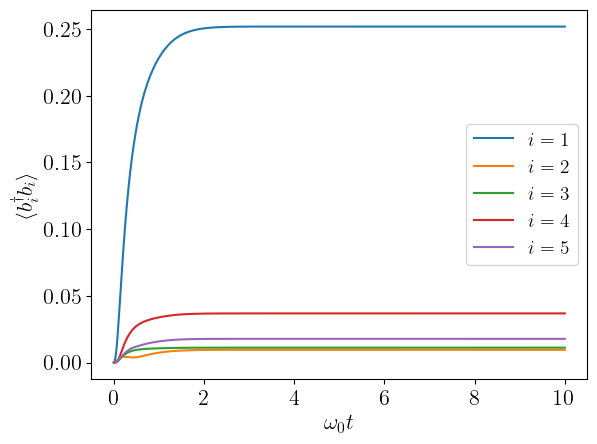

In [85]:
# Pseudomode populations - note these can be negative since the PMME is in quasi-GKSL form
fig6, ax6 = plt.subplots()

for b in range(len(b_ops)):
    ax6.plot(tlist_pm, result.expect[b+2], label=r'$i={}$'.format(b+1))

ax6.set_xlabel(r'$\omega_0 t$')
ax6.set_ylabel(r'$\langle b^{\dagger}_ib_i\rangle $')
ax6.legend()

plt.show()